# **📊 E-Commerce Datenanalyse: Logistik, Zufriedenheit und Kundenbindung**
Projekt-Status: 🟢 Aktiv (Work in Progress)

Dieses Projekt ist eine explorative Datenanalyse (EDA) basierend auf realen E-Commerce-Daten (Olist Dataset). Das übergeordnete Ziel ist es, die geschäftskritische Kausalkette zu untersuchen: Wie beeinflussen Logistikprobleme die Kundenzufriedenheit und wann führen sie zum direkten Kundenverlust (Churn)?

🛠 Tech Stack
Sprache: Python

Data Manipulation: Pandas, NumPy

Datenvisualisierung: Matplotlib, Seaborn

Methodik: Agiles Projektmanagement, Explorative Datenanalyse (EDA)

📈 Projektphasen (Agil & Iterativ)

[x] Phase 1: Das Fundament (Abgeschlossen)
Analyse der direkten Korrelation zwischen realer Lieferzeit (in Tagen) und den abgegebenen Sterne-Bewertungen der Kunden. Identifikation des generellen Unzufriedenheits-Trends.

[x] Phase 2: Hypothesentest Kundenbindung (Abgeschlossen)
Untersuchung der Wiederholungskäufer-Rate in Abhängigkeit der Erstbewertung. **Ergebnis (Plot Twist):** Widerlegung der Ausgangshypothese. Beweis durch Warenkorbanalysen, dass Olist primär langlebige Güter vertreibt und faktisch als Einmalkäufer-Marktplatz agiert.

[ ] Phase 3: Der logistische Kipppunkt (In Arbeit)
Da das Geschäftsmodell zu 100 % auf Neukunden basiert, ist der öffentliche Ruf essenziell. Berechnung des exakten "Tipping Points": Ab welchem Liefertag eskaliert die Unzufriedenheit in toxische Bewertungen (1-3 Sterne), die potenzielle Neukunden abschrecken?

[ ] Phase 4: Der Business-Impact & Umsatzrisiko (Geplant)
Quantifizierung des finanziellen Risikos. Wie viel Umsatz (Risk-Revenue) generieren die Bestellungen, die den logistischen Kipppunkt überschreiten und somit den Ruf der Plattform gefährden?

# Inhaltsverzeichnis
1. [Teil 1: Beziehung zwischen Lieferzeit und Kundenzufriedenheit](#teil-1-wie-beeinflusst-die-lieferzeit-die-kundenzufriedenheit)
2. [Teil 2: Analyse von Wiederkäufern und Churn – Der Einfluss der Kundenzufriedenheit](#teil-2-analyse-von-wiederkäufern-und-churn--der-einfluss-der-kundenzufriedenheit)
3. [Teil 3: Sentiment-Analyse – Der Kipppunkt (Tipping Point) der Lieferzeit](#teil-3-sentiment-analyse--der-kipppunkt-tipping-point-der-lieferzeit)
4. [Teil 4: Business Impact – Berechnung des finanziellen Risikos](#teil-4-business-impact--berechnung-des-finanziellen-risikos)

# <a id="teil1"></a>Teil 1: Wie beeinflusst die Lieferzeit die Kundenzufriedenheit?

Das Problem: Im Online-Handel ist es sehr teuer, neue Kunden zu gewinnen. Deshalb ist es extrem wichtig, dass bestehende Kunden zufrieden sind und wieder einkaufen. Wenn Kunden wegen langen Lieferzeiten unzufrieden sind und nicht mehr bestellen, verliert das Unternehmen viel Geld.

Unsere Forschungsfrage: Welchen messbaren Einfluss hat die Lieferzeit auf die vergebenen Sterne-Bewertungen? Wir wollen den exakten Trend Tag für Tag sichtbar machen. Das Ziel ist es, dem Management mit echten Daten zu beweisen, wie schnell Pakete ankommen müssen, um die Zufriedenheit auf einem profitablen Niveau zu halten.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


### Schritt 1: Daten-Import und Qualitätskontrolle
Die Rohdaten werden geladen. Im Anschluss suchen wir nach Fehlern oder fehlenden Werten in der Tabelle und machen die Daten sauber. Das ist das Fundament für unsere Analyse.

In [2]:
# Kundendaten laden und die ersten 5 Zeilen prüfen
kunden = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
kunden.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
#  Fehlende Werte prüfen
kunden.isnull().sum()


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [4]:
# Bestellungendaten  laden und die ersten 5 Zeilen prüfen
bestellungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
bestellungen.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
#  Fehlende Werte prüfen
bestellungen.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
# Fehlende Werte löschen und nochmal prüfen
bestellungen.dropna(subset=['order_delivered_customer_date'], inplace=True)
bestellungen.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

In [7]:
#  Das Kaufdatum von Text in ein echtes Datum weckseln
bestellungen['order_purchase_timestamp'] = pd.to_datetime(bestellungen['order_purchase_timestamp'])

#  Das Lieferdatum von Text in ein echtes Datum weckseln
bestellungen['order_delivered_customer_date'] = pd.to_datetime(bestellungen['order_delivered_customer_date'])

# Kontrollieren
bestellungen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_status                   96476 non-null  object        
 3   order_purchase_timestamp       96476 non-null  datetime64[ns]
 4   order_approved_at              96462 non-null  object        
 5   order_delivered_carrier_date   96475 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96476 non-null  object        
dtypes: datetime64[ns](2), object(6)
memory usage: 6.6+ MB


### Schritt 2: Die Master-Tabelle erstellen
Die sauberen Einzel-Tabellen werden jetzt zu einer großen Haupt-Tabelle verschmolzen. Als Verbindungsstück zwischen den Tabellen nutzen wir die Spalte `customer_id`. Ab jetzt arbeiten wir nur noch mit dieser zusammengefassten Master-Tabelle.

In [8]:
# Verschmelzen Bestellungen und Kunden zu einer neuen Master-Tabelle
master_tabelle = pd.merge(bestellungen, kunden, on='customer_id', how='inner')
master_tabelle.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### Schritt 3: Berechnung der Lieferdauer in Tagen
Wir erschaffen eine neue Daten-Spalte. Dafür rechnet das System: "Lieferdatum minus Kaufdatum". Das Ergebnis zeigt uns die exakten Liefertage an.

In [9]:
# berechnen  Lieferzeit in Tagen 
master_tabelle['lieferzeit_tage'] = (master_tabelle['order_delivered_customer_date'] - master_tabelle['order_purchase_timestamp']).dt.days

# prüfen mithilfe den relevanten Spalten
master_tabelle[['order_purchase_timestamp', 'order_delivered_customer_date', 'lieferzeit_tage']].head(10)

,order_purchase_timestamp,order_delivered_customer_date,lieferzeit_tage
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2
5,2017-07-09 21:57:05,2017-07-26 10:57:55,16
6,2017-05-16 13:10:30,2017-05-26 12:55:51,9
7,2017-01-23 18:29:09,2017-02-02 14:08:10,9
8,2017-07-29 11:55:02,2017-08-16 17:14:30,18
9,2017-05-16 19:41:10,2017-05-29 11:18:31,12


### Schritt 4: Kundenbewertungen laden und isolieren
Die Lieferzeit allein reicht nicht aus. Wir müssen wissen, wie zufrieden die Kunden waren. Dafür laden wir die Tabelle mit den Bewertungen (1 bis 5 Sterne). Wir filtern sofort die zwei wichtigsten Spalten heraus (Bestellnummer und Sterne) und prüfen diese auf leere Felder, um sauber weiterarbeiten zu können.

In [10]:
# Bewertungsdaten laden 
bewertungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
# Isolieren mit Variablen order_ID und review_score 
bewertungen_isoliert = bewertungen[['order_id', 'review_score']]
# prüfen
bewertungen_isoliert.head()
# prüfen Sauberkeit
bewertungen_isoliert.isnull().sum()

order_id        0
review_score    0
dtype: int64

### Schritt 5: Tabellen zusammenfügen
Wir verbinden die Bewertungen über die Bestellnummer (`order_id`) mit unserer Master-Tabelle. So haben wir Lieferdauer und Sterne-Bewertung endlich zusammen an einem Ort.

In [11]:
# Verschmelzen (Merge)  master_tabelle und bewertungen_isoliert
finale_tabelle = pd.merge(master_tabelle, bewertungen_isoliert, on='order_id', how='inner')
# prüfen
finale_tabelle.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,lieferzeit_tage,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,8,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,13,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,9,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,13,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2,5


### Schritt 6: Den Durchschnitt berechnen (Daten zusammenfassen)
Um ein klares Muster zu erkennen, fassen wir die Daten zusammen. Wir berechnen für jeden einzelnen Liefer-Tag den Durchschnitt der Sterne-Bewertungen. Das ist das finale Fundament für unser Diagramm.

In [12]:
# Durchschnittliche Sterne pro Liefer-Tag berechnen
bewertung_pro_tag = finale_tabelle.groupby('lieferzeit_tage')['review_score'].mean().reset_index()
# runden die Ergebnisse mit 2
bewertung_pro_tag['review_score'] = bewertung_pro_tag['review_score'].round(2)
# prüfen
bewertung_pro_tag.head(10)

,lieferzeit_tage,review_score
0,0,4.23
1,1,4.50
2,2,4.48
3,3,4.43
4,4,4.43
5,5,4.39
6,6,4.38
7,7,4.38
8,8,4.35
9,9,4.30


### Schritt 7: Daten visualisieren (Liniendiagramm)
Tabellen sind schwer zu lesen. Wir wandeln unsere Daten jetzt in ein klares Liniendiagramm um (Fokus auf die ersten 30 Tage). So sehen wir den Trend der Zufriedenheit auf einen Blick.

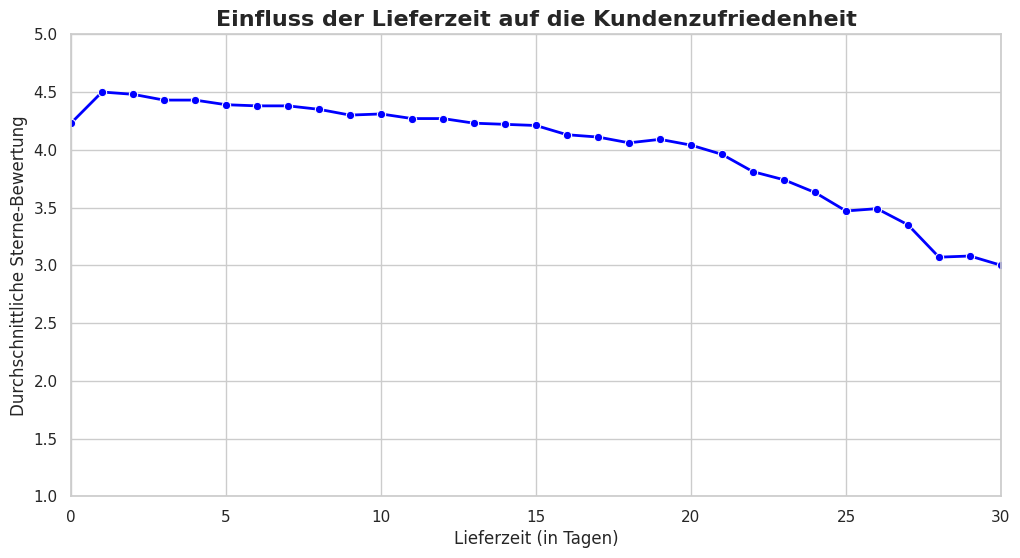

In [13]:
# Wichtige Bibliotheken für Grafiken laden
import matplotlib.pyplot as plt
import seaborn as sns

# Ein sauberes Design auswählen
sns.set_theme(style="whitegrid")

# Die Größe des Diagramms festlegen
plt.figure(figsize=(12, 6))

# Das reine Liniendiagramm zeichnen
sns.lineplot(data=bewertung_pro_tag, x='lieferzeit_tage', y='review_score', marker='o', color='blue', linewidth=2)

# Titel und Achsen beschriften
plt.title('Einfluss der Lieferzeit auf die Kundenzufriedenheit', fontsize=16, fontweight='bold')
plt.xlabel('Lieferzeit (in Tagen)', fontsize=12)
plt.ylabel('Durchschnittliche Sterne-Bewertung', fontsize=12)

# Achsen-Grenzen festlegen (Nur bis Tag 30, Sterne von 1 bis 5)
plt.xlim(0, 30)
plt.ylim(1, 5)

# Diagramm anzeigen
plt.show()

### Fazit zu Frage 1: Was uns das Diagramm zeigt

**1. Die generelle Übersicht und der Ergebnis**
Das Diagramm zeigt ein sehr klares Bild: Je länger ein Kunde auf sein Paket wartet, desto schlechter wird die Bewertung. 
* Bei einer sehr schnellen Lieferung (1 bis 4 Tage) sind die Kunden am glücklichsten und geben im Durchschnitt fast 4,5 Sterne. 
* Danach geht die Linie eindeutig und konstant nach unten. Bei 30 Tagen Wartezeit sind wir bereits bei nur noch 3 Sternen angekommen.

**2. Warum ist die Linie nicht perfekt glatt?**
 Die Kunden bewerten nicht *nur* die Lieferzeit. Ein Paket kann super schnell ankommen, aber wenn das Produkt kaputt ist oder der Paketbote unfreundlich war, gibt es trotzdem nur 1 Stern. Das sorgt für die kleinen Schwankungen in unserer Linie.
 
* **Das Rätsel um "Tag 0":** Warum ist eine Lieferzeit von 0 Tagen (4.23 Sterne) schlechter als 1 Tag (4.50 Sterne)? In der Realität bedeutet "0 Tage" oft, dass es Probleme gab. Zum Beispiel hat der Kunde die Bestellung sofort wieder storniert oder das System hatte einen Fehler. Das macht Kunden wütend und drückt den Durchschnitt nach unten.


# <a id="teil2"></a>Teil 2: Die Beziehung zwischen der Kundenzufriedenheit und der Kundenbindung

 

### Hypothesentest – Der Einfluss der Kundenzufriedenheit auf die Kundenbindung 

**Die Forschungsfrage (Hypothese):**
Ziel dieses Abschnitts ist es, die wissenschaftliche Korrelation zwischen der ersten Kundenerfahrung (Sterne-Bewertung) und der Wahrscheinlichkeit eines erneuten Kaufs (Retention Rate) zu untersuchen. Die logische Ausgangshypothese lautet: Eine hohe Zufriedenheit führt zu einer höheren Kundenbindung.

**Technische Vorbereitung der Daten:**
Bevor wir die Berechnungen durchführen können, müssen wir die relevanten Tabellen korrekt zusammenführen (Mergen). Dabei gibt es eine strukturelle Besonderheit im Datensatz: Das System generiert für jede einzelne Bestellung eine neue `customer_id`. Um echte Wiederkäufer über einen längeren Zeitraum zu identifizieren, müssen wir stattdessen den übergeordneten Schlüssel `customer_unique_id` nutzen. 

Im folgenden Codeblock laden wir die Datensätze und verschaffen uns eine Übersicht, um die exakten Verknüpfungspunkte für unseren Hypothesentest zu finden.

Wir haben den echten Menschen (customer_unique_id) in der Tabelle Kunden.

Wir haben das Bestellticket (order_id) in der Tabelle Bestellungen. Die Brücke dorthin ist die customer_id.

Wir haben die Sterne (review_score) in der Tabelle Bewertungen. Die Brücke dorthin ist die order_id.

In [14]:
# Alle Dateien laden wir einzeln
import pandas as pd

kunden = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
bestellungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
verkäufer = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv')
bewertungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
bestell_artikeln = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
produkte = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
geodaten = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv')
product_kategorien = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')
zahlungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')

# Das Dictionary: Hier verbinden wir den NAMEN mit den DATEN
# Das ist wie ein Inhaltsverzeichnis für die Tabellen
alle_dateien = {
    "Kunden": kunden,
    "Bestellungen": bestellungen,
    "Verkäufer": verkäufer,
    "Bewertungen": bewertungen,
    "Artikel": bestell_artikeln,
    "Produkte": produkte,
    "Geodaten": geodaten,
    "Kategorien": product_kategorien,
    "Zahlungen": zahlungen
}

# Die Schleife: Wir gehen durch das Inhaltsverzeichnis
# Hier 'name' bekommt den Text (z.B. "Kunden"), 'df' bekommt die element
for name, df in alle_dateien.items():
    print(f"--- {name} ---")
    display(df.head(0)) # Zeigt nur die Kopfzeile

--- Kunden ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


--- Bestellungen ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


--- Verkäufer ---


...

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


--- Kategorien ---


,product_category_name,product_category_name_english


--- Zahlungen ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value


### Schritt 1: Daten auf Fehler prüfen
Bevor wir die Tabellen verbinden, prüfen wir unsere Verbindungsstücke (die IDs) auf leere Felder. Nur mit sauberen IDs funktioniert die Verschmelzung fehlerfrei.

In [15]:
print("--- Fehlende Werte bei Kunden ---")
print(kunden[['customer_id', 'customer_unique_id']].isnull().sum())
print("\n--- Fehlende Werte bei Bestellungen ---")
print(bestellungen[['order_id', 'customer_id']].isnull().sum())
print("\n--- Fehlende Werte bei Bewertungen ---")
print(bewertungen[['order_id', 'review_score']].isnull().sum())

--- Fehlende Werte bei Kunden ---
customer_id           0
customer_unique_id    0
dtype: int64

--- Fehlende Werte bei Bestellungen ---
order_id       0
customer_id    0
dtype: int64

--- Fehlende Werte bei Bewertungen ---
order_id        0
review_score    0
dtype: int64


### Schritt 2: Einmalkäufer vs. Wiederkäufer zählen
Da unsere IDs sauber sind, verbinden (mergen) wir nun die Bestellungen mit den Kunden. In dieser neuen Basis-Tabelle schauen wir uns die echte Kunden-ID (`customer_unique_id`) an. Wenn eine ID nur ein einziges Mal in der Liste steht, hat der Kunde nie wieder bestellt (Kundenverlust / Churn). Taucht sie öfter auf, ist es ein Wiederkäufer.

In [16]:
# Verschmelzen von Bestellungen und Kunden über die customer_id
basis_tabelle = pd.merge(bestellungen, kunden, on='customer_id', how='inner')

# Zählen, wie oft jede echte Kunden-ID im System vorkommt
kauf_anzahl = basis_tabelle['customer_unique_id'].value_counts()

# Kunden in zwei Gruppen aufteilen (1 Kauf vs. mehr als 1 Kauf)
einmal_kaeufer = kauf_anzahl[kauf_anzahl == 1]
wieder_kaeufer = kauf_anzahl[kauf_anzahl > 1]

# Wissenschaftliches Ergebnis anzeigen
print(f"Kunden mit genau 1 Einkauf (Abgewandert): {len(einmal_kaeufer)}")
print(f"Kunden mit > 1 Einkauf (Wiederkäufer): {len(wieder_kaeufer)}")

Kunden mit genau 1 Einkauf (Abgewandert): 93099
Kunden mit > 1 Einkauf (Wiederkäufer): 2997


### Schritt 3: Den "Zettel auf die Stirn" kleben
Wir wissen jetzt, wer ein Einmalkäufer und wer ein Wiederkäufer ist. Jetzt markieren wir jeden Kunden in unserer Master-Tabelle mit diesem "Etikett" (Wiederkäufer: Ja oder Nein). Danach sortieren wir die Daten nach Datum, um für jeden Kunden isoliert nur die allererste Bestellung zu betrachten.

In [17]:
#  Den Zettel auf die Stirn kleben: Ist die Kunden-ID in unserer Wiederkäufer-Liste? (True/False)
basis_tabelle['ist_wiederkäufer'] = basis_tabelle['customer_unique_id'].isin(wieder_kaeufer.index)

#  Chronologisch sortieren (Älteste Käufe zuerst)
basis_tabelle = basis_tabelle.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

#  Wir behalten pro Kunde NUR die allererste Zeile (den allerersten Kauf)
erste_bestellungen = basis_tabelle.drop_duplicates(subset=['customer_unique_id'], keep='first')

#  Jetzt holen wir uns die Sterne-Bewertung für exakt diese erste Bestellung dazu
erste_erfahrung = pd.merge(erste_bestellungen, bewertungen_isoliert, on='order_id', how='inner')

#  Kontrolle: Haben wir für jeden Kunden genau eine Zeile?
print(f"Anzahl der Kunden für die Analyse: {len(erste_erfahrung)}")

Anzahl der Kunden für die Analyse: 95653


### Schritt 4: Die Töpfe auswerten (Das finale Experiment)
Jetzt kommt der Moment der Wahrheit: Wir sortieren alle Kunden anhand ihrer allerersten Bewertung in 5 Töpfe (1 bis 5 Sterne). Dann berechnet der Computer für jeden einzelnen Topf: Wie viel Prozent der Kunden darin haben das Etikett "Wiederkäufer = Ja"?

In [18]:
#  Gruppieren nach den 5 Sternen (Die Töpfe)
#  Wir berechnen den Mittelwert (mean) der Spalte 'ist_wiederkäufer'. 
#  Da True=1 und False=0 ist, ergibt der Mittelwert exakt die Prozentzahl!
wiederkauf_rate = erste_erfahrung.groupby('review_score')['ist_wiederkäufer'].mean() * 100

#  Ergebnis runden und als Prozent anzeigen
wiederkauf_rate = wiederkauf_rate.round(2)

print("--- WIEDERKAUF-RATE NACH DEM 1. EINDRUCK ---")
for sterne, prozent in wiederkauf_rate.items():
    print(f"Kunden, die beim 1. Mal {sterne} Sterne gaben, kamen zu {prozent} % wieder.")

--- WIEDERKAUF-RATE NACH DEM 1. EINDRUCK ---
Kunden, die beim 1. Mal 1 Sterne gaben, kamen zu 3.35 % wieder.
Kunden, die beim 1. Mal 2 Sterne gaben, kamen zu 3.22 % wieder.
Kunden, die beim 1. Mal 3 Sterne gaben, kamen zu 3.26 % wieder.
Kunden, die beim 1. Mal 4 Sterne gaben, kamen zu 3.06 % wieder.
Kunden, die beim 1. Mal 5 Sterne gaben, kamen zu 3.42 % wieder.


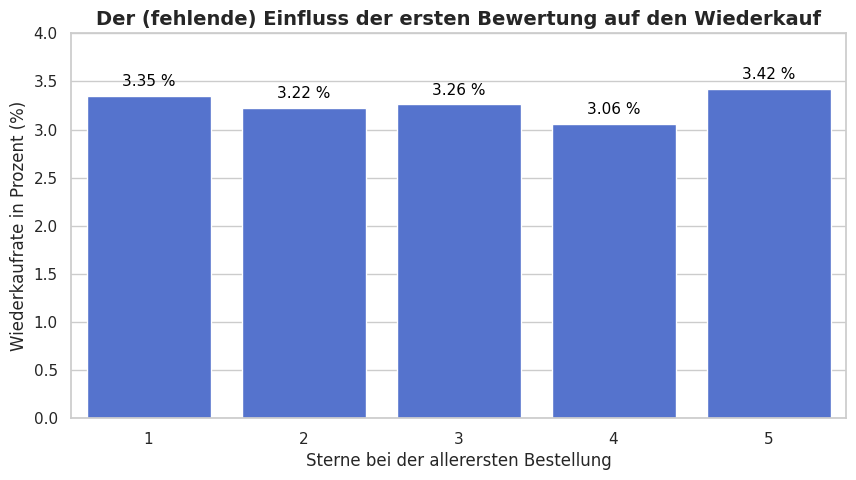

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ein sauberes Design wählen
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Das Balkendiagramm zeichnen (x = Sterne, y = Prozent)
ax = sns.barplot(x=wiederkauf_rate.index, y=wiederkauf_rate.values, color="royalblue")# Titel und Beschriftungen
plt.title('Der (fehlende) Einfluss der ersten Bewertung auf den Wiederkauf', fontsize=14, fontweight='bold')
plt.xlabel('Sterne bei der allerersten Bestellung', fontsize=12)
plt.ylabel('Wiederkaufrate in Prozent (%)', fontsize=12)

# Die genauen Prozentzahlen über die Balken schreiben, damit es richtig gut aussieht
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} %", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Den Y-Achsen-Bereich leicht anpassen, damit die kleinen Unterschiede sichtbar werden
plt.ylim(0, 4)

plt.show()

### Fazit zu Schritt 4: Ein überraschendes Ergebnis
Das Diagramm zeigt uns eine harte wissenschaftliche Wahrheit: Die Sterne-Bewertung hat fast keinen Einfluss auf die Wiederkaufrate. Egal ob der Kunde sein erstes Paket liebt (5 Sterne) oder hasst (1 Stern), die Chance auf einen zweiten Kauf bleibt fast gleich niedrig (knapp über 3 %). Der Grund dafür ist das Marktplatz-Geschäftsmodell, bei dem Kunden generell nur für Einzelkäufe kommen.

Da wir hier an eine analytische Grenze stoßen, wechseln wir nun die Methode. Wir drehen die Perspektive komplett um und schauen uns das Problem von der anderen Seite an.

### Schritt 5: Die Perspektive wechseln (Sterne-Verteilung pro Gruppe)
Wir drehen die Frage um. Anstatt zu fragen, wie viele 5-Sterne-Bewerter zurückkommen, fragen wir: "Aus welchen Erstbewertungen setzen sich unsere treuen Wiederkäufer eigentlich zusammen?" Dafür vergleichen wir die prozentuale Sterne-Verteilung der Einmalkäufer direkt mit der Verteilung der Wiederkäufer.

In [20]:
# 1. Wir trennen unsere Master-Tabelle in zwei separate Gruppen
einmal_gruppe = erste_erfahrung[erste_erfahrung['ist_wiederkäufer'] == False]
wieder_gruppe = erste_erfahrung[erste_erfahrung['ist_wiederkäufer'] == True]

# 2. Wir berechnen für jede Gruppe, wie viel Prozent 1, 2, 3, 4 oder 5 Sterne gaben.
# normalize=True rechnet automatisch den prozentualen Anteil aus (anstatt nur zu zählen).
verteilung_einmal = (einmal_gruppe['review_score'].value_counts(normalize=True) * 100).sort_index()
verteilung_wieder = (wieder_gruppe['review_score'].value_counts(normalize=True) * 100).sort_index()

# 3. Wir packen beide Ergebnisse in eine übersichtliche Tabelle zum direkten Vergleich
vergleichs_tabelle = pd.DataFrame({
    'Einmalkäufer (%)': verteilung_einmal.round(2),
    'Wiederkäufer (%)': verteilung_wieder.round(2)
})

# Tabelle hübsch anzeigen
print("--- VERTEILUNG DER ERSTEN STERNE-BEWERTUNG ---")
display(vergleichs_tabelle)

--- VERTEILUNG DER ERSTEN STERNE-BEWERTUNG ---


,Einmalkäufer (%),Wiederkäufer (%)
review_score,,
1,11.53,11.61
2,3.19,3.08
3,8.25,8.09
4,19.45,17.85
5,57.59,59.36


### Schritt 6: Der visuelle Beweis
Um final zu verdeutlichen, dass die Kundenzufriedenheit keinen Einfluss auf die Kundentreue hat, visualisieren wir die Tabelle als gruppiertes Balkendiagramm. Es zeigt eindrucksvoll: Die Sterne-Verteilung ist bei Einmalkäufern und treuen Kunden nahezu identisch.

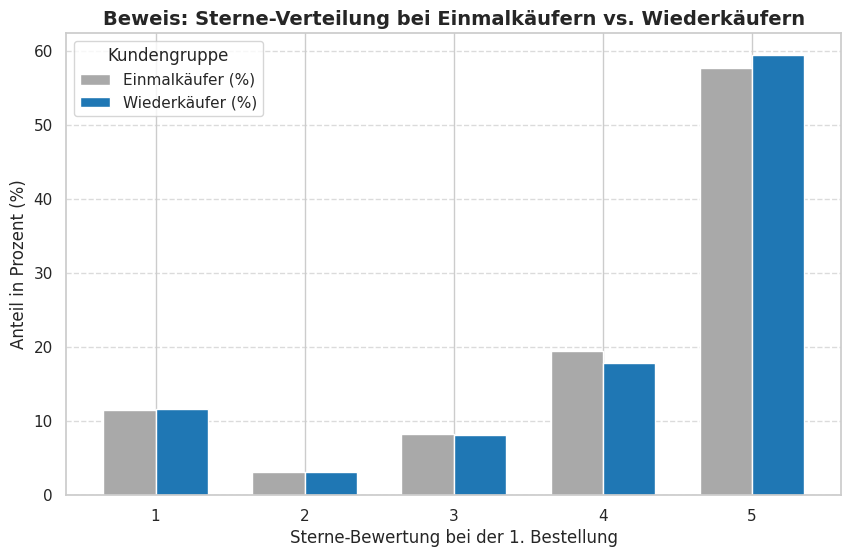

In [21]:
import matplotlib.pyplot as plt

# 1. Wir nutzen die plot-Funktion von Pandas, die automatisch Matplotlib im Hintergrund verwendet
ax = vergleichs_tabelle.plot(kind='bar', figsize=(10, 6), width=0.7, color=['#A9A9A9', '#1f77b4'])

# 2. Titel und Achsen professionell beschriften
plt.title('Beweis: Sterne-Verteilung bei Einmalkäufern vs. Wiederkäufern', fontsize=14, fontweight='bold')
plt.xlabel('Sterne-Bewertung bei der 1. Bestellung', fontsize=12)
plt.ylabel('Anteil in Prozent (%)', fontsize=12)

# 3. Die Zahlen auf der X-Achse (1 bis 5) waagerecht drehen, damit sie lesbar sind
plt.xticks(rotation=0)

# 4. Legende anpassen
plt.legend(title='Kundengruppe', fontsize=11)

# 5. Raster im Hintergrund für den wissenschaftlichen Look
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Schritt 7: Warum kommen die Kunden nicht zurück?

Die bisherige Analyse zeigt ein klares, datengetriebenes Bild: Es gibt prozentual nahezu keinen Unterschied bei der Wiederkaufrate zwischen den verschiedenen Sterne-Bewertungen. Das bedeutet im Umkehrschluss: Ob der Kunde ein perfektes (5 Sterne) oder ein katastrophales (1 Stern) Erlebnis hatte – er kehrt so oder so nicht zurück. 

Um dieses zunächst unlogisch wirkende Verhalten zu erklären, müssen wir das Kernsortiment von Olist analysieren. In welche Konsumkategorie fallen die verkauften Produkte? Handelt es sich um Verbrauchsgüter, die in kurzen Abständen immer wieder neu gekauft werden müssen (z. B. Lebensmittel), oder um langlebige Gebrauchsgüter, die über Jahre hinweg genutzt werden (sodass der Kunde nach einem einmaligen Kauf schlichtweg lange Zeit keinen neuen Bedarf hat)? 

Die folgende Analyse der meistverkauften Kategorien liefert den wissenschaftlichen Beweis zur Beantwortung dieser Frage.

In [22]:

#  Artikel und Produkte verbinden (mit deinen echten Variablennamen)
produkt_verkäufe = pd.merge(bestell_artikeln, produkte, on='product_id', how='inner')

#  Kategorien hinzufügen für englische Namen
produkt_verkäufe_komplett = pd.merge(produkt_verkäufe, product_kategorien, on='product_category_name', how='inner')

#  Top 5 berechnen
top_5_kategorien = produkt_verkäufe_komplett['product_category_name_english'].value_counts().head(5)

#  Anzeigen
print("--- TOP 5 MEISTVERKAUFTE PRODUKTKATEGORIEN ---")
print(top_5_kategorien)

--- TOP 5 MEISTVERKAUFTE PRODUKTKATEGORIEN ---
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
Name: count, dtype: int64


### Executive Summary (Fazit Teil 2): Die datengetriebene Realität des Geschäftsmodells

Die Daten widerlegen unsere Ausgangshypothese eindeutig: Es gibt keine statistische Korrelation zwischen der Erstbewertung und der Kundenbindung. Sowohl bei katastrophalen (1 Stern) als auch bei perfekten (5 Sterne) Erfahrungen liegt die Wiederkaufrate konstant bei nur rund 3 %. 

**Der wissenschaftliche Beweis:**
Unsere Analyse der Top-5-Kategorien liefert den unwiderlegbaren Beweis für dieses Kundenverhalten. Olist vertreibt primär langlebige Gebrauchsgüter (wie Bettwäsche, Möbel, Sportgeräte und Computerzubehör). Das bedeutet: Olist funktioniert faktisch als reiner Marktplatz für Einmalkäufer. Die Kunden decken einen spezifischen, selten auftretenden Bedarf und haben danach schlichtweg über Jahre hinweg keinen Grund zurückzukehren – völlig unabhängig davon, wie zufrieden sie mit dem Service waren.

**Handlungsempfehlung an das Management:**
Sämtliche Budgets für klassische Kundenbindungsprogramme (z. B. Rabattcodes für den zweiten Einkauf oder Treue-Newsletter) müssen sofort gestoppt werden, da sie in diesem Geschäftsmodell ins Leere laufen. Das Überleben der Firma hängt zu 100 % von der kontinuierlichen Akquise von Neukunden ab. 



# <a id="teil3"></a>Teil 3: Sentiment-Analyse – Der Kipppunkt der Lieferzeit



**Das geschäftliche Problem:**
Da wir in Teil 2 bewiesen haben, dass Olist fast ausschließlich von Neukunden lebt, ist der öffentliche Ruf (Reviews) die wichtigste Währung des Unternehmens. Wenn zu lange Lieferzeiten zu schlechten Bewertungen führen, schreckt das potenzielle Neukunden ab und gefährdet das gesamte Geschäftsmodell. 

**Die Forschungsfrage:**
In diesem Abschnitt führen wir eine Sentiment-Analyse durch, um das Risiko einer toxischen Bewertung zu quantifizieren. Ab welchem exakten Liefertag kippt die Stimmung der Kunden statistisch ins Negative? Wir suchen den Punkt, an dem das Risiko einer 1-bis-3-Sterne-Bewertung die 50 %-Marke überschreitet.

### Schritt 1: Definition von „Fan“ vs. „Kritiker“ (Segmentierung)

In [23]:
#  Wir starten mit einer sauberen Kopie der Bewertungsdaten
df_sentiment = bewertungen.copy()

#  Die harte Gruppierung (Klassifizierung)
# 4 & 5 Punkte = Fan (False)
# 1, 2 & 3 Punkte = Kritiker (True)
df_sentiment['ist_kritiker'] = np.where(df_sentiment['review_score'] <= 3, True, False)

#  Überprüfung der Gruppierung
# Zeige die ersten 10 Zeilen zur Kontrolle
print("--- ERGEBNIS DER GRUPPIERUNG ---")
print(df_sentiment[['review_score', 'ist_kritiker']].head(10))

--- ERGEBNIS DER GRUPPIERUNG ---
   review_score  ist_kritiker
0             4         False
1             5         False
2             5         False
3             5         False
4             5         False
5             1          True
6             5         False
7             5         False
8             5         False
9             4         False


### Schritt 2: Datenintegration und Kipppunkt-Berechnung
In diesem Schritt führen wir die Sentiment-Daten mit den Logistik-Informationen zusammen und berechnen die Eskalationsrate der Kundenunzufriedenheit in Abhängigkeit von der Lieferzeit.

Vorgehensweise:

1. Daten-Merge: Zusammenführung von Kundenbewertungen und Bestelldaten.

2. Zeit-Berechnung: Ermittlung der tatsächlichen Lieferdauer in Tagen.

3. Kipppunkt-Aggregation: Berechnung des prozentualen Anteils der Kritiker pro Liefertag.

In [24]:
# 1. Zusammenführung der Daten
df_analyse = pd.merge(df_sentiment, 
                      bestellungen[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']], 
                      on='order_id', how='inner')

# 2. Berechnung der Lieferdauer in Tagen
df_analyse['purchase'] = pd.to_datetime(df_analyse['order_purchase_timestamp'])
df_analyse['delivered'] = pd.to_datetime(df_analyse['order_delivered_customer_date'])
df_analyse['lieferzeit_tage'] = (df_analyse['delivered'] - df_analyse['purchase']).dt.days

#  Bereinigung
df_analyse = df_analyse.dropna(subset=['lieferzeit_tage'])
df_analyse = df_analyse[df_analyse['lieferzeit_tage'] >= 0]

# 3. Berechnung und Erstellung der sauberen Tabelle
df_tabelle = df_analyse.groupby('lieferzeit_tage')['ist_kritiker'].mean().reset_index()
df_tabelle['ist_kritiker'] = (df_tabelle['ist_kritiker'] * 100).round(1)

#  Finale Spaltennamen und Ausgabe
df_tabelle.columns = ['Lieferzeit_in_Tagen', 'Kritiker_Anteil_in_Prozent']

print("--- ANALYSE-ERGEBNIS ---")
print(df_tabelle.head(40).to_string(index=False))

--- ANALYSE-ERGEBNIS ---
 Lieferzeit_in_Tagen  Kritiker_Anteil_in_Prozent
                 0.0                        23.1
                 1.0                        12.0
                 2.0                        12.2
                 3.0                        13.6
                 4.0                        13.2
                 5.0                        14.8
                 6.0                        14.7
                 7.0                        15.0
                 8.0                        15.5
                 9.0                        16.6
                10.0                        16.3
                11.0                        18.1
                12.0                        17.6
                13.0                        18.6
                14.0                        19.4
                15.0                        19.4
                16.0                        21.1
                17.0                        22.9
                18.0                        

### Visualisierung und statistische Einordnung: Der "Kipppunkt" der Logistik

Die folgende Grafik illustriert die Korrelation zwischen der Lieferdauer (in Tagen) und dem Anteil der "Kritiker" (Kunden mit 1-3 Sternen). 

**Methodik:**
Um die Aussagekraft der Daten zu gewährleisten, wurde die Analyse auf die ersten 30 Tage fokussiert. Dieser Bereich deckt die Mehrheit der Liefervorgänge ab und bietet eine statistisch relevante Datenbasis. Die rot markierte Kurve zeigt die Eskalationsrate der Unzufriedenheit.



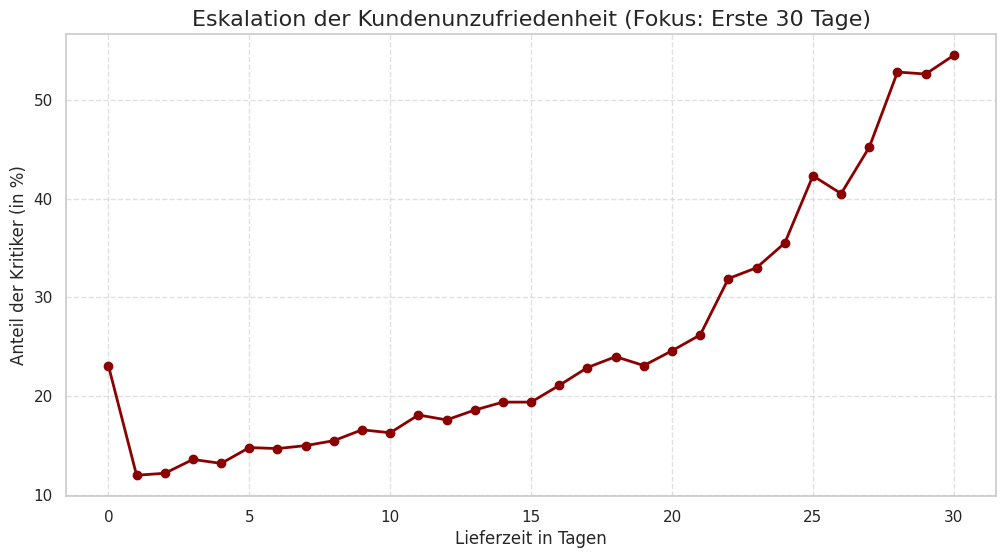

In [25]:
import matplotlib.pyplot as plt

#  Daten auf die ersten 30 Tage einschränken (statistisch signifikant)
df_plot = df_tabelle[df_tabelle['Lieferzeit_in_Tagen'] <= 30]

#  Diagramm erstellen
plt.figure(figsize=(12, 6))
plt.plot(df_plot['Lieferzeit_in_Tagen'], df_plot['Kritiker_Anteil_in_Prozent'], 
         marker='o', linestyle='-', color='darkred', linewidth=2, label="Kritiker-Anteil")

#  Titel und Achsenbeschriftung
plt.title("Eskalation der Kundenunzufriedenheit (Fokus: Erste 30 Tage)", fontsize=16)
plt.xlabel("Lieferzeit in Tagen", fontsize=12)
plt.ylabel("Anteil der Kritiker (in %)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

#  Diagramm anzeigen
plt.show()